# 02 — Model Architecture & Training

This notebook covers the denoising model itself: how its architecture was chosen, what each part of it does, and how it is trained on the preprocessed SNSD spectrograms from [01_Preprocessing.ipynb](01_Preprocessing.ipynb).


In [1]:
%load_ext autoreload
%autoreload 2

## From a Simple Autoencoder to a U-Net

Model development followed a fairly standard path: **simple convolutional encoder-decoder → identify limitations → introduce U-Net skip connections → tune architecture → freeze final configuration.**

The first model, `ConvDenoisingAutoencoder` ([model_conv.py](../src/models/model_conv.py)), is a plain encoder-decoder: three strided convolutions compress the spectrogram down, three transposed convolutions expand it back. It was useful for validating the training pipeline end-to-end (data loading, loss, optimizer, checkpointing) quickly, but as a pure bottleneck autoencoder it struggled to recover fine spectro-temporal detail lost during compression — denoised outputs were plausible in overall shape but lost sharpness in transient/high-frequency content.

That limitation motivated moving to a **U-Net** (`UNet` in [model_unet.py](../src/models/model_unet.py)), which keeps the same encoder-decoder philosophy but adds skip connections between corresponding encoder/decoder levels.


## Why U-Net Makes Sense Here

Denoising can be formulated as a supervised image-to-image regression problem in the time-frequency domain: the network receives a noisy magnitude spectrogram and learns to predict its clean counterpart. Convolutions are a good match for this task because speech and noise differ in local spectro-temporal patterns—structure across nearby time-frequency bins—that convolutional kernels can learn to distinguish.

The encoder progressively builds a lower-resolution, higher-channel representation that captures broader context, while the decoder reconstructs a full-resolution clean estimate. **Skip connections** carry features from each encoder level to the corresponding decoder level, allowing fine timing and frequency detail to bypass the bottleneck and complement the coarser context learned along the deeper path. This is particularly useful for preserving sharp harmonics and transient speech components.

This is the central idea of the U-Net architecture, originally proposed for biomedical image segmentation (Ronneberger, Fischer & Brox, [*U-Net: Convolutional Networks for Biomedical Image Segmentation*, 2015](https://arxiv.org/abs/1505.04597)). Applying it here treats the magnitude spectrogram as a single-channel image and denoising as a time-frequency-bin-wise regression problem.

<!-- TODO: add the encoder/decoder diagram from the original U-Net paper here -->

## Final Architecture

```
Noisy Spectrogram  [1 × 257 × 1024]
        │
        ▼
   Encoder (3 levels)
   16 → 32 → 64 channels
   (Conv block + MaxPool at each level)
        │
        ▼
    Bottleneck
      128 channels
        │
        ▼
   Decoder (3 levels) + Skip Connections
   64 → 32 → 16 channels
   (Upconv + concat with matching encoder skip + Conv block)
        │
        ▼
Estimated Clean Spectrogram [1 × 257 × 1024]
```

Each encoder level halves the spatial resolution while doubling the number of channels; each decoder level does the reverse, doubling the resolution back and halving the channels, while re-injecting the corresponding skip connection before its convolution block. The bottleneck sits at the point of maximum compression: lowest resolution, most channels.


## Key Parameters

`UNet(in_channels=1, out_channels=1, base_filters=16, depth=3, dropout_rate=0.1)`

- **`base_filters`** — number of channels produced by the first encoder level (16 here). Every deeper level doubles it (`base_filters * 2**d`), so `depth=3` gives encoder channel counts of 16 → 32 → 64, and a bottleneck of `64 * 2 = 128`.
- **`depth`** — number of encoder/decoder levels. Each encoder level ends with a `MaxPool2d(2)` (halving time and frequency resolution); each decoder level starts with a `ConvTranspose2d` (doubling it back).
- **Skip connections** — the pre-pooling activation from each encoder level is concatenated to the corresponding decoder level's upsampled output, before that level's convolution block. Because 257 frequency bins doesn't halve evenly, the model includes a bilinear-resize fallback (`_match_and_concat`) so the skip tensor and the upsampled tensor always line up before concatenation.
- **Dropout** — applied twice per convolution block (once after each of its two convolutions), i.e. at every encoder, bottleneck, and decoder level, as regularization against the model memorizing noise patterns specific to the training set.

Together, the encoder progressively trades spatial resolution for a wider, more abstract channel representation, the bottleneck holds the most compressed representation, and the decoder mirrors the encoder back up while continuously blending in the finer-grained skip features.


## Model Summary

A layer-by-layer summary makes the channel/resolution trade-off above concrete, showing the exact tensor shape and parameter count at every stage for a single 8-second clip (`1 × 257 × 1024`).


In [ ]:
from src.models.model_unet import UNet

preview_model = UNet(base_filters=16, depth=3, dropout_rate=0.1)
preview_model.summary(input_size=(1, 257, 1024))


In [4]:
import sys

sys.path.append("..")

# Local Modules
from src.training import train_model
from src.dataprocess.torch_dataset_SNSD import DenoisingSpectrogramDataset
from torch.utils.data import DataLoader

# Path to Dataset
DATA_DIR = "/media/gabriel/500 BKP/datasets/SNSD-DataSet/preprocessed"
TARGET_FRAMES = 1024

# Dataset and loader
train_dataset = DenoisingSpectrogramDataset(DATA_DIR, 'train', TARGET_FRAMES)
val_dataset = DenoisingSpectrogramDataset(DATA_DIR, 'validation', TARGET_FRAMES)

# Dataloader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, persistent_workers=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, persistent_workers=False)

## Training Configuration

- **Loss**: Mean Squared Error (`nn.MSELoss`) between the predicted and clean magnitude spectrograms — a natural fit since both are dense, continuous-valued arrays of the same shape, and MSE directly penalizes deviations at every time-frequency bin.
- **Optimizer**: Adam, a reasonable default for a convolutional architecture like this one, adapting the learning rate per-parameter from running estimates of the gradient's first and second moments.
- **Learning rate scheduling**: `ReduceLROnPlateau` reduces the learning rate (`factor=0.1`) whenever validation loss hasn't improved for `patience=2` epochs, letting the optimizer take large steps early on and smaller, more careful steps as training converges.
- **Early stopping**: training is capped at `num_epochs=100`, but stops early if validation loss hasn't improved for `early_stopping_patience=10` epochs. Only the best-performing checkpoint (by validation loss) is saved, to `tuning/checkpoints/`.
- **Progress monitoring**: `audio_preview=True` triggers a listen-and-look preview (`play_denoised_sample`) every 5 epochs, rendering noisy/denoised/clean spectrograms side by side and playing the corresponding audio — useful for catching qualitative issues (e.g. artifacts) that a scalar loss value alone wouldn't reveal.


Using device: cuda

🔁 Epoch 1/100


✅ Best model saved (val loss: 0.0319)

🎧 Previewing model output at epoch 0:


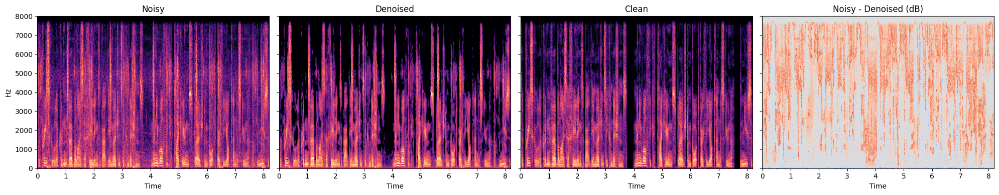

🔊 Noisy


🔊 Denoised (model output)


🔊 Clean (reference)


📉 Train Loss: 0.0822 | Val Loss: 0.0319
🔧 Learning Rate: 0.001000

🔁 Epoch 2/100


⚠️  No improvement for 1 epoch(s)
📉 Train Loss: 0.0410 | Val Loss: 0.0330
🔧 Learning Rate: 0.001000

🔁 Epoch 3/100


✅ Best model saved (val loss: 0.0227)
📉 Train Loss: 0.0351 | Val Loss: 0.0227
🔧 Learning Rate: 0.001000

🔁 Epoch 4/100


⚠️  No improvement for 1 epoch(s)
📉 Train Loss: 0.0313 | Val Loss: 0.0236
🔧 Learning Rate: 0.001000

🔁 Epoch 5/100


✅ Best model saved (val loss: 0.0201)
📉 Train Loss: 0.0292 | Val Loss: 0.0201
🔧 Learning Rate: 0.001000

🔁 Epoch 6/100


✅ Best model saved (val loss: 0.0173)

🎧 Previewing model output at epoch 5:


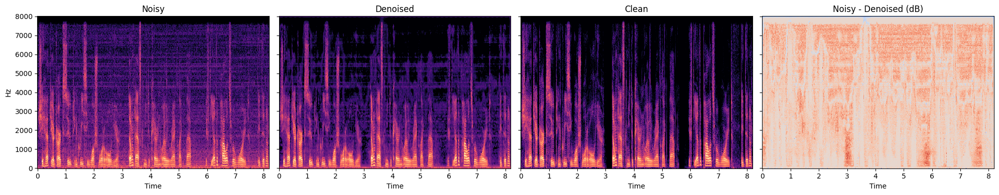

🔊 Noisy


🔊 Denoised (model output)


🔊 Clean (reference)


📉 Train Loss: 0.0273 | Val Loss: 0.0173
🔧 Learning Rate: 0.001000

🔁 Epoch 7/100


⚠️  No improvement for 1 epoch(s)
📉 Train Loss: 0.0262 | Val Loss: 0.0197
🔧 Learning Rate: 0.001000

🔁 Epoch 8/100


⚠️  No improvement for 2 epoch(s)
📉 Train Loss: 0.0244 | Val Loss: 0.0209
🔧 Learning Rate: 0.001000

🔁 Epoch 9/100


Epoch 00009: reducing learning rate of group 0 to 1.0000e-04.
⚠️  No improvement for 3 epoch(s)
📉 Train Loss: 0.0239 | Val Loss: 0.0175
🔧 Learning Rate: 0.000100

🔁 Epoch 10/100


⚠️  No improvement for 4 epoch(s)
📉 Train Loss: 0.0222 | Val Loss: 0.0177
🔧 Learning Rate: 0.000100

🔁 Epoch 11/100


⚠️  No improvement for 5 epoch(s)

🎧 Previewing model output at epoch 10:


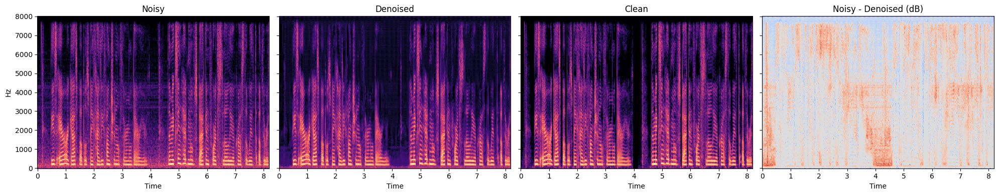

🔊 Noisy


🔊 Denoised (model output)


🔊 Clean (reference)


📉 Train Loss: 0.0218 | Val Loss: 0.0175
🔧 Learning Rate: 0.000100

🔁 Epoch 12/100


Epoch 00012: reducing learning rate of group 0 to 1.0000e-05.
⚠️  No improvement for 6 epoch(s)
📉 Train Loss: 0.0217 | Val Loss: 0.0173
🔧 Learning Rate: 0.000010

🔁 Epoch 13/100


⚠️  No improvement for 7 epoch(s)
📉 Train Loss: 0.0215 | Val Loss: 0.0176
🔧 Learning Rate: 0.000010

🔁 Epoch 14/100


⚠️  No improvement for 8 epoch(s)
📉 Train Loss: 0.0215 | Val Loss: 0.0179
🔧 Learning Rate: 0.000010

🔁 Epoch 15/100


Epoch 00015: reducing learning rate of group 0 to 1.0000e-06.
⚠️  No improvement for 9 epoch(s)
📉 Train Loss: 0.0215 | Val Loss: 0.0178
🔧 Learning Rate: 0.000001

🔁 Epoch 16/100


⚠️  No improvement for 10 epoch(s)
⛔️ Early stopping triggered.


In [5]:
import torch
from torch import nn, optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Model
from src.models.model_unet import UNet

# Step 1: Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Step 2: Create model and move to device
model = UNet(dropout_rate = 0.1).to(device)

# Step 3: Set up optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Step 4: Set up learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',            # we're minimizing val loss
    factor=0.1,            # reduce LR by this factor (e.g. halve it)
    patience=2,            # wait this many epochs before reducing
    verbose=True           # print update info
)

# Step 5: Call training loop
model, train_losses, val_losses = train_model(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=device,
    train_loader=train_loader,
    train_dataset=train_dataset,
    val_loader=val_loader,
    val_dataset=val_dataset,
    num_epochs=100,
    early_stopping_patience=10,
    audio_preview=True
)

## Results


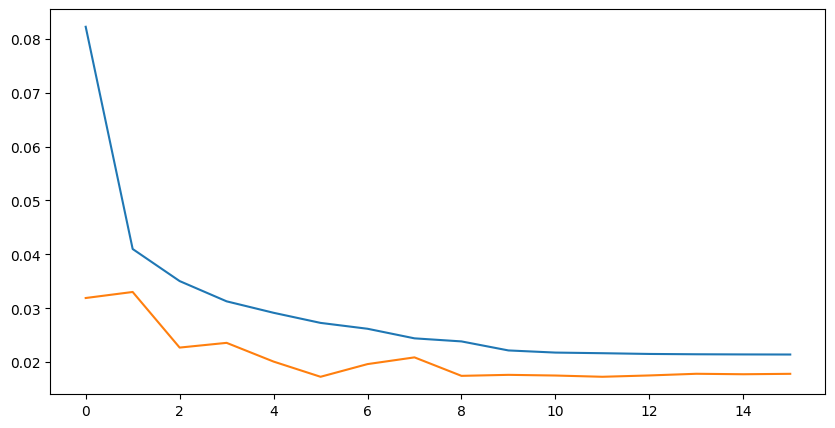

In [6]:
import matplotlib.pyplot as plt

# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

Training and validation loss decrease together before leveling off, with no substantial or sustained divergence between the curves. This suggests that the model converged without a clear increase in overfitting during the run; subsequent evaluation therefore uses the checkpoint with the lowest validation loss rather than the weights from the final epoch.

## Listening & Inspecting a Sample


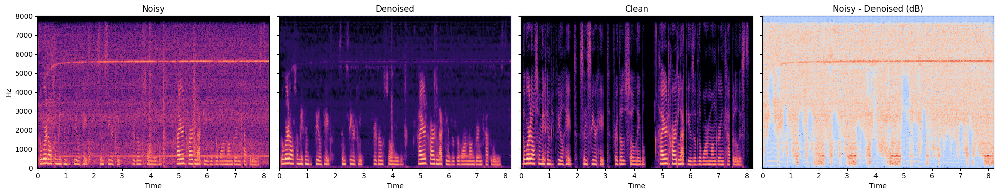

🔊 Noisy


🔊 Denoised (model output)


🔊 Clean (reference)


In [7]:
from src.utils import play_denoised_sample, plot_spectrograms

play_denoised_sample(model, val_dataset, index=0)

In this validation example, the denoised output suppresses much of the broadband background energy while retaining the dominant speech structure visible in the clean reference. The corresponding audio sounds clearer than the noisy input, although some residual noise and slight smoothing of fine detail remain; the model improves intelligibility without fully reproducing the clean target.

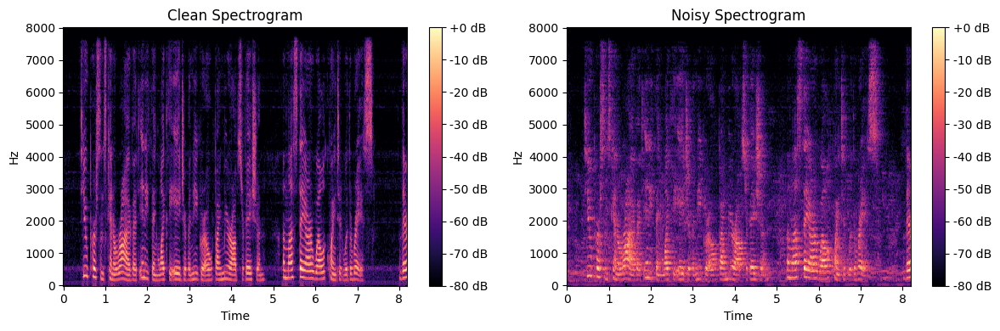

In [52]:
import librosa

plot_spectrograms(val_dataset[0][1], val_dataset[0][0])